In [1]:
import random
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from itertools import product
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from itertools import permutations

import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
class Sat_Generator:

    def __init__(self,n,m):
        self.value = int(random.uniform(10**n,10**(n+1)))
        self.elements = int(random.uniform(10**m,10**(m+1)))
        self.operators = [" not "," or "," and "]
        self.final_string = ""
    
    def rules_to_generator(self,limit=10):
        str_final = ""
        arr_rules = list(str(self.value))
        arr_elements = list(str(self.elements))

        for iter in range(limit):
            group = int(random.uniform(0,len(arr_rules)))
            str_final += "("
            for i,element in enumerate(arr_elements):
                str_final += f"x_{element}"
                op = self.operators[int(i) % len(self.operators)]
                str_final += op
                if group == i-1:
                    str_final += f"x_{arr_elements[i]}"
                    str_final += ")"
                    if iter == limit:
                        break
                    else:
                        str_final += random.choice(self.operators)
                        break
        self.final_string = str_final
                
    def print_final_string(self):
        print(self.final_string)

                





In [3]:
satGen = Sat_Generator(3,3)
satGen.rules_to_generator()
satGen.print_final_string()

(x_3 not x_1 or x_1) and (x_3 not x_1 or x_1 and x_1) not (x_3 not x_1 or x_1 and x_3 not x_3) not (x_3 not x_1 or x_1) and (x_3 not x_1 or x_1) not (x_3 not x_1 or x_1 and x_3 not x_3) not (x_3 not x_1 or x_1) not (x_3 not x_1 or x_1 and x_3 not (x_3 not x_1 or x_1) or (x_3 not x_1 or x_1) and 


In [4]:
class encodeSystem:

    def __init__(self,n):
        self.chain = [random.choice((0,1)) for i in range(n)]
        self.ops = [1,2,3,4]
        self.meaning = [" and not ", " or not" , " and ", " or "]
        self.ops_set = []

    def print_chain(self):
        print(self.chain)

    def return_chain(self):
        return self.chain
    def set_ops(self):
        self.ops_set = [random.choice(self.ops) for i in range(len(self.chain))]

    def return_ops_set(self):
        return self.ops_set
    
    def get_ops_set(self,val):
        self.ops_set = val

    def set_chain(self,chain):
        self.chain = chain

    def determine_sat(self,op=False):
        new_chain = []
        for i,val in enumerate(self.chain):
            if i < len(self.chain)-1:
                x = self.ops_set[i]
                if len(new_chain) > 0:
                    value_cond = new_chain[-1]
                else:
                    value_cond = self.chain[i]
                    
                if value_cond != self.chain[i+1]:
                    if x == 1:
                        new_chain.append(self.chain[i])
                    elif x == 2:
                        new_chain.append(self.chain[i])
                    elif x == 3:
                        new_chain.append(0)
                    else:
                        new_chain.append(1)
                else:
                    if x == 1:
                        new_chain.append(0)
                    elif x == 2:
                        new_chain.append(1)
                    elif x == 3:
                        new_chain.append(self.chain[i])
                    else:
                        new_chain.append(self.chain[i])
        

        if self.chain == new_chain or len(new_chain) == 1 or len(self.chain) == 1:
            #print(f"final chain {self.chain}")
            self.chain = new_chain
            return self.chain
        else:
            #print(new_chain,"new chain")
            self.chain = new_chain
            self.determine_sat()

In [5]:
code = encodeSystem(5)
code.print_chain()
chain = code.return_chain()
code.set_ops()
chain_final = code.determine_sat()


[0, 1, 1, 0, 0]


In [6]:
def repeated_permutations(elements, r):
    return list(product(elements, repeat=r))

In [7]:

def repeated_permutations(elements, r):
    return list(product(elements, repeat=r))

X = []
y = []
n = 6
group_op = [1,2,3,4]
group_bool = [0,1]

op_values = repeated_permutations(group_op,n-1)
bool_values = repeated_permutations(group_bool,n)

for group_op in op_values:
    for bool_val in bool_values:
        bool_val = list(bool_val)
        code = encodeSystem(n)
        code.set_chain(bool_val)
        code.get_ops_set(group_op)
        code.determine_sat()
        chain_final = code.return_chain()
        ops_set = list(group_op)
        #print(f"ops_set {ops_set}")
        bool_val.extend(ops_set)
        #print(chain,chain_final)
        X.append(bool_val)
        y.extend(chain_final)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)


clf = RandomForestClassifier()
clf.fit(X_train,y_train)

pred = clf.predict(X_test)

value = balanced_accuracy_score(pred,y_test)




In [8]:

def repeated_permutations(elements, r):
    return list(product(elements, repeat=r))

def calculate_permutation_sat_ml(n):
    X = []
    y = []
    group_op = [1,2,3,4]
    group_bool = [0,1]

    op_values = repeated_permutations(group_op,n-1)
    bool_values = repeated_permutations(group_bool,n)

    for group_op in op_values:
        for bool_val in bool_values:
            bool_val = list(bool_val)
            code = encodeSystem(n)
            code.set_chain(bool_val)
            code.get_ops_set(group_op)
            code.determine_sat()
            chain_final = code.return_chain()
            ops_set = list(group_op)
            #print(f"ops_set {ops_set}")
            bool_val.extend(ops_set)
            #print(chain,chain_final)
            X.append(bool_val)
            y.extend(chain_final)


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.33, random_state=42)


    clf = RandomForestClassifier()
    clf.fit(X_train,y_train)

    pred = clf.predict(X_test)

    value = balanced_accuracy_score(pred,y_test)
    return value



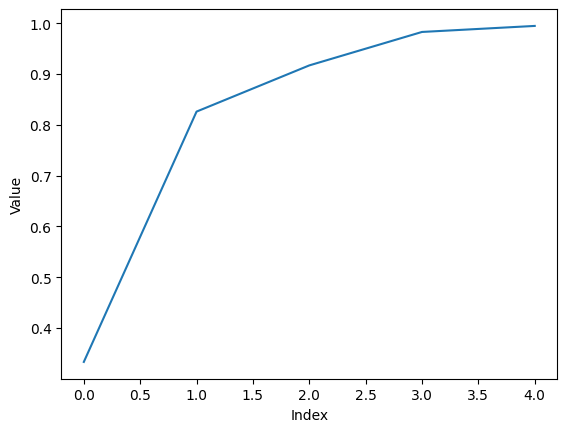

In [9]:
pred_data = []
for i in range(2,7):
    val = calculate_permutation_sat_ml(i)
    pred_data.append(val)

sns.lineplot(x=range(len(pred_data)), y=pred_data)
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()


In [10]:

def repeated_permutations(elements, r):
    return list(product(elements, repeat=r))

def calculate_sat_ml(n):
    X = []
    y = []
    group_op = [1,2,3,4]

    op_values = repeated_permutations(group_op,n-1)

    for group_op in op_values:
        code = encodeSystem(n)
        code.get_ops_set(group_op)
        code.determine_sat()
        chain_final = code.return_chain()
        ops_set = list(group_op)
        #print(f"ops_set {ops_set}")
        #print(chain,chain_final)
        X.append(ops_set)
        y.extend(chain_final)


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.33, random_state=42)


    clf = RandomForestClassifier()
    clf.fit(X_train,y_train)

    pred = clf.predict(X_test)

    value = balanced_accuracy_score(pred,y_test)
    return value



c:\Users\brs_c\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


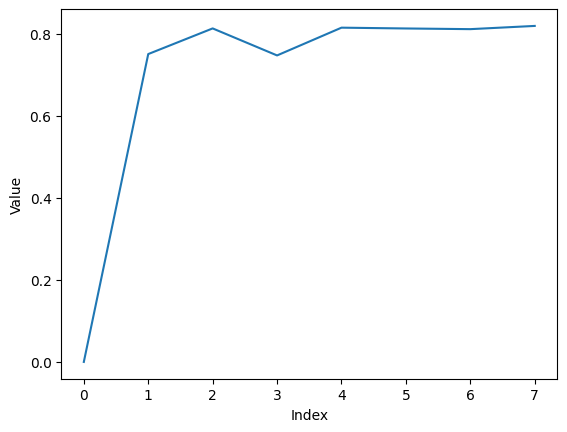

In [11]:
pred_data = []
for i in range(2,10):
    val = calculate_sat_ml(i)
    pred_data.append(val)

sns.lineplot(x=range(len(pred_data)), y=pred_data)
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

In [12]:
class CorrectionSat:

    def __init__(self,n):
        self.chain = [random.choice((0,1)) for i in range(n)]
        self.ops = [1,2,3,4]
        self.meaning = [" and not ", " or not" , " and ", " or "]
        self.ops_set = []

    def print_chain(self):
        print(self.chain)

    def return_chain(self):
        return self.chain
    def set_ops(self):
        self.ops_set = [random.choice(self.ops) for i in range(len(self.chain)-1)]

    def return_ops_set(self):
        return self.ops_set
    
    def get_ops_set(self,val):
        self.ops_set = val

    def set_chain(self,chain):
        self.chain = chain


    def determine_sat(self):
        val = self.chain[0]
        for i,val in enumerate(self.chain):
            if i < len(self.chain)-1:
                x = self.ops_set[i]

                if val == self.chain[i+1]:
                    if x == 1:
                        pass
                    elif x == 2:
                        pass
                    elif x == 3:
                        val = 0
                    else:
                        val = 1
                    
                else:
                    if x == 1:
                        val = 0
                    elif x == 2:
                        val = 1
                    elif x == 3:
                        pass
                    else:
                        pass

        return val

In [13]:
code = CorrectionSat(10)
code.set_ops()

code.determine_sat()

1

In [14]:
def repeated_permutations(elements, r):
    return list(product(elements, repeat=r))

def calculate_sat_ml_quick(n):
    X = []
    y = []
    group_op = [1,2,3,4]

    op_values = repeated_permutations(group_op,n-1)

    for group_op in op_values:
        code = CorrectionSat(n)
        code.get_ops_set(group_op)
        chain_final = code.determine_sat()
        ops_set = list(group_op)
        #print(f"ops_set {ops_set}")
        #print(chain,chain_final)
        X.append(ops_set)
        y.extend([chain_final])


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.33, random_state=42)


    clf = RandomForestClassifier()
    clf.fit(X_train,y_train)

    pred = clf.predict(X_test)

    value = balanced_accuracy_score(pred,y_test)
    return value

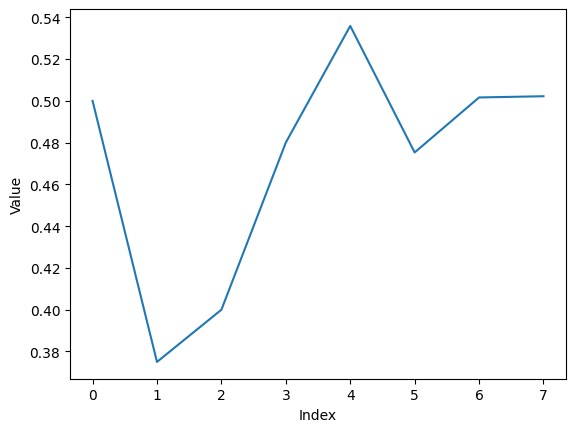

In [15]:
pred_data = []
for i in range(2,10):
    val = calculate_sat_ml_quick(i)
    pred_data.append(val)

sns.lineplot(x=range(len(pred_data)), y=pred_data)
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()